# Trustworthiness Evaluation

## 1. Research Objective

This notebook is now an artifact-only trustworthiness analysis. It does **not** train, refit, load checkpoints, or rerun any forecasting model. All authoritative model forecasts are loaded from `../results/validated_forecasts.csv`.

The goal is to evaluate point accuracy, robustness, temporal generalisation, uncertainty calibration, explainability, and overall trustworthiness using saved forecast vectors and reproducible deterministic baselines only.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.6f}".format)

ARTIFACT_ONLY = True
MODEL_FITTING_EXECUTED = False
MODEL_CHECKPOINT_LOADED = False
FORECAST_VECTOR_REGENERATED = False


## 2. Load Authoritative Forecast Artifact

Expected artifact: `../results/validated_forecasts.csv`

Required columns:
- `Timestamp`
- `Actual`
- `Naive`
- `Persistence_Enhanced_LSTM`
- `Chronos_Bolt_Tiny`
- `TimesFM`


In [2]:
forecast_artifact_path = PROJECT_ROOT / "results" / "validated_forecasts.csv"
forecast_results = pd.read_csv(forecast_artifact_path, parse_dates=["Timestamp"])

expected_columns = [
    "Timestamp",
    "Actual",
    "Naive",
    "Persistence_Enhanced_LSTM",
    "Chronos_Bolt_Tiny",
    "TimesFM",
]

missing_columns = [column for column in expected_columns if column not in forecast_results.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

forecast_results = forecast_results[expected_columns].sort_values("Timestamp").reset_index(drop=True)
forecast_results["Timestamp"] = pd.to_datetime(forecast_results["Timestamp"], utc=True)
forecast_results = forecast_results.set_index("Timestamp")

value_columns = ["Actual", "Naive", "Persistence_Enhanced_LSTM", "Chronos_Bolt_Tiny", "TimesFM"]

artifact_validation = pd.DataFrame(
    [
        {"Check": "Shape is (1061, 6) before Timestamp index", "Result": tuple(pd.read_csv(forecast_artifact_path).shape) == (1061, 6)},
        {"Check": "Timestamp unique", "Result": forecast_results.index.is_unique},
        {"Check": "Timestamp sorted", "Result": forecast_results.index.is_monotonic_increasing},
        {"Check": "No missing values", "Result": not forecast_results[value_columns].isna().any().any()},
        {"Check": "All forecast values finite", "Result": bool(np.isfinite(forecast_results[value_columns].to_numpy(dtype=float)).all())},
        {"Check": "Exact test start date", "Result": forecast_results.index.min() == pd.Timestamp("2023-08-12", tz="UTC")},
        {"Check": "Exact test end date", "Result": forecast_results.index.max() == pd.Timestamp("2026-07-07", tz="UTC")},
        {"Check": "Test length is 1061", "Result": len(forecast_results) == 1061},
    ]
)

model_vector_frame = forecast_results[["Naive", "Persistence_Enhanced_LSTM", "Chronos_Bolt_Tiny", "TimesFM"]]
duplicate_vector_rows = []
for left_position, left_name in enumerate(model_vector_frame.columns):
    for right_name in model_vector_frame.columns[left_position + 1:]:
        duplicate_vector_rows.append(
            {
                "Pair": f"{left_name} vs {right_name}",
                "Duplicated Vector": bool(model_vector_frame[left_name].equals(model_vector_frame[right_name])),
            }
        )
duplicate_vector_check = pd.DataFrame(duplicate_vector_rows)
artifact_validation.loc[len(artifact_validation)] = {
    "Check": "No duplicated forecast vectors",
    "Result": not duplicate_vector_check["Duplicated Vector"].any(),
}

display(artifact_validation)
duplicate_vector_check


,Check,Result
0,"Shape is (1061, 6) before Timestamp index",True
1,Timestamp unique,True
2,Timestamp sorted,True
3,No missing values,True
4,All forecast values finite,True
5,Exact test start date,True
6,Exact test end date,True
7,Test length is 1061,True
8,No duplicated forecast vectors,True


,Pair,Duplicated Vector
0,Naive vs Persistence_Enhanced_LSTM,False
1,Naive vs Chronos_Bolt_Tiny,False
2,Naive vs TimesFM,False
3,Persistence_Enhanced_LSTM vs Chronos_Bolt_Tiny,False
4,Persistence_Enhanced_LSTM vs TimesFM,False
5,Chronos_Bolt_Tiny vs TimesFM,False


## 3. Load Dataset And Verify Split

In [3]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"
raw_df = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(raw_df)
target = df_daily["Close"].dropna().astype(float).rename("Close")

split_idx = int(len(target) * 0.8)
train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = forecast_results["Actual"].rename("Actual")

split_validation = pd.DataFrame(
    [
        {"Check": "Train ends 2023-08-11", "Result": train.index.max() == pd.Timestamp("2023-08-11", tz="UTC")},
        {"Check": "Test begins 2023-08-12", "Result": test.index.min() == pd.Timestamp("2023-08-12", tz="UTC")},
        {"Check": "Test length is 1061", "Result": len(test) == 1061},
        {"Check": "Artifact index equals reconstructed test index", "Result": forecast_results.index.equals(test.index)},
        {"Check": "Artifact Actual equals reconstructed Close", "Result": np.allclose(forecast_results["Actual"], test.to_numpy(dtype=float))},
    ]
)
split_validation


,Check,Result
0,Train ends 2023-08-11,True
1,Test begins 2023-08-12,True
2,Test length is 1061,True
3,Artifact index equals reconstructed test index,True
4,Artifact Actual equals reconstructed Close,True


## 4. Forecast Protocol Comparability

The main Trust Score ranking includes only rolling one-step models with exact saved vectors or deterministic no-leakage baselines. ARIMA and SARIMA are retained as separate protocol notes unless exact rolling one-step saved vectors exist.


In [4]:
available_result_files = {path.name for path in (PROJECT_ROOT / "results").glob("*")}
original_lstm_vector_exists = "original_lstm_forecast.csv" in available_result_files or "Original_LSTM" in forecast_results.columns
arima_rolling_vector_exists = "arima_rolling_forecast.csv" in available_result_files or "ARIMA_Rolling" in forecast_results.columns
sarima_rolling_vector_exists = "sarima_rolling_forecast.csv" in available_result_files or "SARIMA_Rolling" in forecast_results.columns

protocol_comparability = pd.DataFrame(
    [
        {"Model": "Naive", "Model Type": "Classical baseline", "Protocol": "Rolling one-step", "Saved Vector": True, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "7-Day Moving Average", "Model Type": "Classical baseline", "Protocol": "Deterministic rolling one-step", "Saved Vector": False, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "Persistence-Enhanced LSTM", "Model Type": "Supervised deep learning", "Protocol": "Rolling one-step", "Saved Vector": True, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "TimesFM", "Model Type": "Zero-shot time-series foundation model", "Protocol": "Rolling one-step", "Saved Vector": True, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "Chronos-Bolt-Tiny", "Model Type": "Zero-shot time-series foundation model", "Protocol": "Rolling one-step", "Saved Vector": True, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "Original LSTM", "Model Type": "Supervised deep learning", "Protocol": "Exploratory historical workflow", "Saved Vector": original_lstm_vector_exists, "Uses newly observed test actuals": np.nan, "Eligible for main Trust Score": "Yes" if original_lstm_vector_exists else "No"},
        {"Model": "ARIMA(1,1,1)", "Model Type": "Statistical model", "Protocol": "Static multi-step unless saved rolling vector exists", "Saved Vector": arima_rolling_vector_exists, "Uses newly observed test actuals": False, "Eligible for main Trust Score": "Yes" if arima_rolling_vector_exists else "No"},
        {"Model": "SARIMA", "Model Type": "Statistical model", "Protocol": "Static multi-step unless saved rolling vector exists", "Saved Vector": sarima_rolling_vector_exists, "Uses newly observed test actuals": False, "Eligible for main Trust Score": "Yes" if sarima_rolling_vector_exists else "No"},
    ]
).set_index("Model")
protocol_comparability


,Model Type,Protocol,Saved Vector,Uses newly observed test actuals,Eligible for main Trust Score
Model,,,,,
Naive,Classical baseline,Rolling one-step,True,True,Yes
7-Day Moving Average,Classical baseline,Deterministic rolling one-step,False,True,Yes
Persistence-Enhanced LSTM,Supervised deep learning,Rolling one-step,True,True,Yes
TimesFM,Zero-shot time-series foundation model,Rolling one-step,True,True,Yes
Chronos-Bolt-Tiny,Zero-shot time-series foundation model,Rolling one-step,True,True,Yes
Original LSTM,Supervised deep learning,Exploratory historical workflow,False,NaN,No
"ARIMA(1,1,1)",Statistical model,Static multi-step unless saved rolling vector ...,False,False,No
SARIMA,Statistical model,Static multi-step unless saved rolling vector ...,False,False,No


## 5. Accuracy Evaluation

In [5]:
forecast_series = {
    "Naive": forecast_results["Naive"].rename("Naive"),
    "Persistence-Enhanced LSTM": forecast_results["Persistence_Enhanced_LSTM"].rename("Persistence-Enhanced LSTM"),
    "TimesFM": forecast_results["TimesFM"].rename("TimesFM"),
    "Chronos-Bolt-Tiny": forecast_results["Chronos_Bolt_Tiny"].rename("Chronos-Bolt-Tiny"),
}

# Deterministic no-leakage 7-day moving average: prediction at t uses t-7 through t-1 only.
moving_average_7 = target.shift(1).rolling(window=7).mean().reindex(test.index).rename("7-Day Moving Average")
assert moving_average_7.index.equals(y_test.index)
assert not moving_average_7.isna().any()

ma7_audit = pd.DataFrame(
    {
        "forecast_date": test.index[:10],
        "window_start": [target.loc[:date].iloc[:-1].tail(7).index.min() for date in test.index[:10]],
        "window_end": [target.loc[:date].iloc[:-1].tail(7).index.max() for date in test.index[:10]],
        "forecast": moving_average_7.iloc[:10].to_numpy(dtype=float),
        "actual": y_test.iloc[:10].to_numpy(dtype=float),
    }
)
assert (pd.to_datetime(ma7_audit["window_end"]) < pd.to_datetime(ma7_audit["forecast_date"])).all()
forecast_series["7-Day Moving Average"] = moving_average_7

if original_lstm_vector_exists:
    if "Original_LSTM" in forecast_results.columns:
        forecast_series["Original LSTM"] = forecast_results["Original_LSTM"].rename("Original LSTM")
    else:
        original_lstm_path = PROJECT_ROOT / "results" / "original_lstm_forecast.csv"
        original_lstm_df = pd.read_csv(original_lstm_path, parse_dates=["Timestamp"]).set_index("Timestamp")
        if original_lstm_df.index.tz is None:
            original_lstm_df.index = original_lstm_df.index.tz_localize("UTC")
        forecast_series["Original LSTM"] = original_lstm_df.iloc[:, 0].reindex(y_test.index).rename("Original LSTM")

metrics_rows = []
for model_name, forecast in forecast_series.items():
    metrics_rows.append(
        {
            "Model": model_name,
            "MAE": mae(y_test, forecast),
            "RMSE": rmse(y_test, forecast),
            "MAPE": mape(y_test, forecast),
            "sMAPE": smape(y_test, forecast),
            "N": len(pd.concat([y_test, forecast], axis=1).dropna()),
        }
    )

metrics_table = pd.DataFrame(metrics_rows).set_index("Model")
metrics_table["Relative MAE"] = metrics_table["MAE"] / metrics_table.loc["Naive", "MAE"]
metrics_table.sort_values("RMSE")


,MAE,RMSE,MAPE,sMAPE,N,Relative MAE
Model,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,1061,1.000000
Persistence-Enhanced LSTM,1323.040782,1886.566387,1.787392,1.794338,1061,1.025332
TimesFM,1349.946786,1924.199337,1.823179,1.823895,1061,1.046184
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,1061,1.103594
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,1061,1.712536


## 6. Robustness Evaluation

In [6]:
returns = y_test.pct_change()
rolling_volatility = returns.rolling(window=14, min_periods=7).std()
low_threshold = rolling_volatility.quantile(0.33)
high_threshold = rolling_volatility.quantile(0.67)
up_threshold = returns.quantile(0.80)
down_threshold = returns.quantile(0.20)

regime_masks = {
    "Low Volatility": rolling_volatility <= low_threshold,
    "High Volatility": rolling_volatility >= high_threshold,
    "Major Upward Movement": returns >= up_threshold,
    "Major Downward Movement": returns <= down_threshold,
}

regime_rows = []
for regime_name, mask in regime_masks.items():
    regime_index = mask[mask].index
    for model_name, forecast in forecast_series.items():
        regime_rows.append(
            {
                "Regime": regime_name,
                "Model": model_name,
                "MAE": mae(y_test.reindex(regime_index), forecast.reindex(regime_index)),
                "RMSE": rmse(y_test.reindex(regime_index), forecast.reindex(regime_index)),
                "MAPE": mape(y_test.reindex(regime_index), forecast.reindex(regime_index)),
                "sMAPE": smape(y_test.reindex(regime_index), forecast.reindex(regime_index)),
                "N": len(regime_index),
            }
        )

regime_performance = pd.DataFrame(regime_rows).set_index(["Regime", "Model"]).sort_index()
regime_performance


MAE        RMSE  \
Regime                  Model                                               
High Volatility         7-Day Moving Average      2682.163896 3614.703600   
                        Chronos-Bolt-Tiny         1864.388500 2557.524924   
                        Naive                     1693.012098 2377.559838   
                        Persistence-Enhanced LSTM 1732.965445 2432.174814   
                        TimesFM                   1725.906316 2431.334540   
Low Volatility          7-Day Moving Average      1687.232225 2213.797897   
                        Chronos-Bolt-Tiny         1083.427281 1471.093619   
                        Naive                      945.739741 1330.423874   
                        Persistence-Enhanced LSTM  979.656484 1367.665756   
                        TimesFM                   1004.046175 1395.964951   
Major Downward Movement 7-Day Moving Average      2963.258605 3937.339129   
                        Chronos-Bolt-Tiny         2676.764417 3143.316897   
                        Naive                     2405.814387 2783.990155   
                        Persistence-Enhanced LSTM 2153.678020 2565.605265   
                        TimesFM                   2454.908958 2875.542493   
Major Upward Movement   7-Day Moving Average      2869.267655 3628.681105   
                        Chronos-Bolt-Tiny         2259.397087 2709.867140   
                        Naive                     2470.870708 2847.611203   
                        Persistence-Enhanced LSTM 2691.037096 3081.192748   
                        TimesFM                   2467.687670 2877.414558   

                                                      MAPE    sMAPE    N  
Regime                  Model                                             
High Volatility         7-Day Moving Average      3.857638 3.871668  348  
                        Chronos-Bolt-Tiny         2.683194 2.678018  348  
                        Naive                     2.421755 2.429165  348  
                        Persistence-Enhanced LSTM 2.484760 2.500432  348  
                        TimesFM                   2.463589 2.468897  348  
Low Volatility          7-Day Moving Average      2.198762 2.213027  348  
                        Chronos-Bolt-Tiny         1.377116 1.373214  348  
                        Naive                     1.180756 1.181645  348  
                        Persistence-Enhanced LSTM 1.222909 1.226762  348  
                        TimesFM                   1.262562 1.264101  348  
Major Downward Movement 7-Day Moving Average      4.066642 3.940151  212  
                        Chronos-Bolt-Tiny         3.642255 3.555488  212  
                        Naive                     3.273488 3.205404  212  
                        Persistence-Enhanced LSTM 2.935082 2.877192  212  
                        TimesFM                   3.353373 3.279358  212  
Major Upward Movement   7-Day Moving Average      3.990346 4.099324  212  
                        Chronos-Bolt-Tiny         3.065887 3.132953  212  
                        Naive                     3.374531 3.448803  212  
                        Persistence-Enhanced LSTM 3.660069 3.746333  212  
                        TimesFM                   3.379197 3.454914  212

## 7. Generalisation Evaluation

In [7]:
segment_rows = []
for segment_name, segment_index in zip(
    ["Earlier Test Period", "Middle Test Period", "Later Test Period"],
    np.array_split(y_test.index, 3),
):
    for model_name, forecast in forecast_series.items():
        segment_rows.append(
            {
                "Segment": segment_name,
                "Model": model_name,
                "MAE": mae(y_test.reindex(segment_index), forecast.reindex(segment_index)),
                "RMSE": rmse(y_test.reindex(segment_index), forecast.reindex(segment_index)),
                "MAPE": mape(y_test.reindex(segment_index), forecast.reindex(segment_index)),
                "sMAPE": smape(y_test.reindex(segment_index), forecast.reindex(segment_index)),
                "N": len(segment_index),
            }
        )

segment_generalisation = pd.DataFrame(segment_rows).set_index(["Segment", "Model"]).sort_index()
segment_generalisation


MAE        RMSE  \
Segment             Model                                               
Earlier Test Period 7-Day Moving Average      1613.532284 2246.462544   
                    Chronos-Bolt-Tiny         1033.215942 1531.946847   
                    Naive                      936.257062 1408.715265   
                    Persistence-Enhanced LSTM  967.640739 1435.051344   
                    TimesFM                    959.797107 1447.154027   
Later Test Period   7-Day Moving Average      2421.860579 3228.992440   
                    Chronos-Bolt-Tiny         1569.593481 2128.869810   
                    Naive                     1401.305354 1931.860167   
                    Persistence-Enhanced LSTM 1426.451743 1953.199313   
                    TimesFM                   1466.605426 2019.309963   
Middle Test Period  7-Day Moving Average      2594.534705 3394.693166   
                    Chronos-Bolt-Tiny         1669.679268 2247.404213   
                    Naive                     1533.810734 2142.906579   
                    Persistence-Enhanced LSTM 1575.321985 2191.748397   
                    TimesFM                   1623.767368 2221.895875   

                                                  MAPE    sMAPE    N  
Segment             Model                                             
Earlier Test Period 7-Day Moving Average      3.171577 3.203620  354  
                    Chronos-Bolt-Tiny         2.008502 2.005858  354  
                    Naive                     1.796095 1.801253  354  
                    Persistence-Enhanced LSTM 1.860610 1.869183  354  
                    TimesFM                   1.856881 1.863368  354  
Later Test Period   7-Day Moving Average      2.815708 2.778245  353  
                    Chronos-Bolt-Tiny         1.825621 1.813796  353  
                    Naive                     1.626706 1.621078  353  
                    Persistence-Enhanced LSTM 1.651603 1.654087  353  
                    TimesFM                   1.711244 1.701637  353  
Middle Test Period  7-Day Moving Average      3.077563 3.090063  354  
                    Chronos-Bolt-Tiny         1.969097 1.966368  354  
                    Naive                     1.805111 1.809746  354  
                    Persistence-Enhanced LSTM 1.849581 1.859349  354  
                    TimesFM                   1.901097 1.906334  354

## 8. Uncertainty Evaluation

Foundation-model uncertainty uses validated native interval results from Notebook 05:

- Chronos-Bolt-Tiny: 80% coverage `0.845429`, average 80% width `5151.959961`, 95% unavailable.
- TimesFM: 80% coverage `0.330820`, average 80% width `1436.627452`, 95% unavailable.

TimesFM intervals are narrow but severely under-cover. This materially lowers its Uncertainty Score.

For deterministic baselines without native probabilistic forecasts, validation-period residuals are used only when they can be recreated without model fitting. Persistence-Enhanced LSTM has no saved validation uncertainty artifact, so it receives an explicit uncertainty penalty rather than invented intervals.


In [8]:
validation_window = train.iloc[-len(test):]
validation_actual = validation_window.rename("actual")
validation_index = validation_actual.index

validation_forecasts = {
    "Naive": target.shift(1).reindex(validation_index).rename("Naive"),
    "7-Day Moving Average": target.shift(1).rolling(window=7).mean().reindex(validation_index).rename("7-Day Moving Average"),
}

uncertainty_rows = []
for model_name, validation_forecast in validation_forecasts.items():
    aligned_validation = pd.concat([validation_actual, validation_forecast.rename("forecast")], axis=1).dropna()
    residual_abs = (aligned_validation["actual"] - aligned_validation["forecast"]).abs()
    q80 = residual_abs.quantile(0.80)
    q95 = residual_abs.quantile(0.95)
    test_error_abs = (y_test - forecast_series[model_name]).abs()
    uncertainty_rows.append(
        {
            "Model": model_name,
            "80% Coverage": (test_error_abs <= q80).mean(),
            "Average 80% Width": 2 * q80,
            "95% Coverage": (test_error_abs <= q95).mean(),
            "Average 95% Width": 2 * q95,
            "Interval Type": "Validation residual-based empirical interval",
            "Note": "No test residuals used for calibration.",
        }
    )

uncertainty_rows.extend(
    [
        {
            "Model": "Persistence-Enhanced LSTM",
            "80% Coverage": np.nan,
            "Average 80% Width": np.nan,
            "95% Coverage": np.nan,
            "Average 95% Width": np.nan,
            "Interval Type": "Unavailable",
            "Note": "No saved validation uncertainty artifact; penalised rather than invented.",
        },
        {
            "Model": "Chronos-Bolt-Tiny",
            "80% Coverage": 0.845429,
            "Average 80% Width": 5151.959961,
            "95% Coverage": np.nan,
            "Average 95% Width": np.nan,
            "Interval Type": "Native foundation-model quantile interval",
            "Note": "95% unavailable; unsupported quantiles not extrapolated.",
        },
        {
            "Model": "TimesFM",
            "80% Coverage": 0.330820,
            "Average 80% Width": 1436.627452,
            "95% Coverage": np.nan,
            "Average 95% Width": np.nan,
            "Interval Type": "Native foundation-model quantile interval",
            "Note": "95% unavailable; verified quantile range only 0.1 through 0.9. Narrow intervals severely under-cover.",
        },
    ]
)

uncertainty_table = pd.DataFrame(uncertainty_rows).set_index("Model").reindex(metrics_table.index)
uncertainty_table


,80% Coverage,Average 80% Width,95% Coverage,Average 95% Width,Interval Type,Note
Model,,,,,,
Naive,0.656927,2766.580000,0.903864,5985.980000,Validation residual-based empirical interval,No test residuals used for calibration.
Persistence-Enhanced LSTM,NaN,NaN,NaN,NaN,Unavailable,No saved validation uncertainty artifact; pena...
TimesFM,0.330820,1436.627452,NaN,NaN,Native foundation-model quantile interval,95% unavailable; verified quantile range only ...
Chronos-Bolt-Tiny,0.845429,5151.959961,NaN,NaN,Native foundation-model quantile interval,95% unavailable; unsupported quantiles not ext...
7-Day Moving Average,0.667295,5119.605714,0.909519,10181.151429,Validation residual-based empirical interval,No test residuals used for calibration.


## 9. Explainability Evaluation

In [9]:
explainability_table = pd.DataFrame(
    {
        "Naive": {
            "Model Transparency": 100,
            "Ease of Interpretation": 100,
            "Computational Complexity": 100,
            "Reproducibility": 100,
            "Failure Detectability": 95,
        },
        "7-Day Moving Average": {
            "Model Transparency": 95,
            "Ease of Interpretation": 95,
            "Computational Complexity": 100,
            "Reproducibility": 100,
            "Failure Detectability": 90,
        },
        "Persistence-Enhanced LSTM": {
            "Model Transparency": 45,
            "Ease of Interpretation": 50,
            "Computational Complexity": 45,
            "Reproducibility": 75,
            "Failure Detectability": 70,
        },
        "Chronos-Bolt-Tiny": {
            "Model Transparency": 35,
            "Ease of Interpretation": 45,
            "Computational Complexity": 90,
            "Reproducibility": 90,
            "Failure Detectability": 85,
        },
        "TimesFM": {
            "Model Transparency": 30,
            "Ease of Interpretation": 40,
            "Computational Complexity": 75,
            "Reproducibility": 90,
            "Failure Detectability": 80,
        },
    }
).T.reindex(metrics_table.index)
explainability_table["Explainability Score"] = explainability_table.mean(axis=1)
explainability_table


,Model Transparency,Ease of Interpretation,Computational Complexity,Reproducibility,Failure Detectability,Explainability Score
Model,,,,,,
Naive,100,100,100,100,95,99.000000
Persistence-Enhanced LSTM,45,50,45,75,70,57.000000
TimesFM,30,40,75,90,80,63.000000
Chronos-Bolt-Tiny,35,45,90,90,85,69.000000
7-Day Moving Average,95,95,100,100,90,96.000000


## 10. Trust Score Framework

Weights:
- Relative Accuracy Score: 35%
- Relative Robustness Score: 20%
- Relative Generalisation Score: 20%
- Uncertainty Score: 15%
- Explainability Score: 10%

A score of 100 is relative to the best model in the comparison set and does not represent perfect forecast accuracy.


In [10]:
weights = {
    "Relative Accuracy Score": 0.35,
    "Relative Robustness Score": 0.20,
    "Relative Generalisation Score": 0.20,
    "Uncertainty Score": 0.15,
    "Explainability Score": 0.10,
}


def inverse_score(values):
    values = pd.Series(values, dtype=float)
    best = values.min()
    return (100 * best / values).clip(0, 100)


relative_accuracy_score = inverse_score(metrics_table["RMSE"])

robustness_rmse = regime_performance["RMSE"].unstack("Regime")
robustness_penalty = robustness_rmse.mean(axis=1) + robustness_rmse.std(axis=1).fillna(0)
relative_robustness_score = inverse_score(robustness_penalty)

generalisation_rmse = segment_generalisation["RMSE"].unstack("Segment")
generalisation_penalty = generalisation_rmse.mean(axis=1) + generalisation_rmse.std(axis=1).fillna(0)
relative_generalisation_score = inverse_score(generalisation_penalty)

coverage_component = (100 - (uncertainty_table["80% Coverage"] - 0.80).abs() * 100).clip(0, 100)
width_component = inverse_score(uncertainty_table["Average 80% Width"].dropna())
uncertainty_score = (0.90 * coverage_component + 0.10 * width_component.reindex(coverage_component.index)).clip(0, 100)
uncertainty_score = uncertainty_score.fillna(0)

explainability_score = explainability_table["Explainability Score"]

trust_scores = pd.DataFrame(
    {
        "Relative Accuracy Score": relative_accuracy_score,
        "Relative Robustness Score": relative_robustness_score,
        "Relative Generalisation Score": relative_generalisation_score,
        "Uncertainty Score": uncertainty_score,
        "Explainability Score": explainability_score,
    }
).dropna()

trust_scores["Overall Trust Score"] = sum(trust_scores[column] * weight for column, weight in weights.items())
trust_scores = trust_scores.sort_values("Overall Trust Score", ascending=False)
trust_scores


,Relative Accuracy Score,Relative Robustness Score,Relative Generalisation Score,Uncertainty Score,Explainability Score,Overall Trust Score
Model,,,,,,
Naive,100.000000,100.000000,100.000000,82.316260,99.000000,97.247439
Chronos-Bolt-Tiny,92.959750,95.434840,93.750212,88.699897,69.000000,90.577907
TimesFM,96.332263,98.149743,95.992177,57.773800,63.000000,87.510746
Persistence-Enhanced LSTM,98.253885,98.545144,98.173252,0.000000,57.000000,79.432539
7-Day Moving Average,61.795627,73.698764,61.660333,80.862680,96.000000,70.429691


## 11. Trust Score Validation

In [11]:
component_columns = list(weights)
weighted_sum = sum(trust_scores[column] * weight for column, weight in weights.items())
trust_score_validation = pd.DataFrame(
    [
        {
            "Check": "All component scores between 0 and 100",
            "Result": bool(((trust_scores[component_columns] >= 0) & (trust_scores[component_columns] <= 100)).all().all()),
        },
        {
            "Check": "No NaN Trust Scores",
            "Result": bool(not trust_scores[component_columns + ["Overall Trust Score"]].isna().any().any()),
        },
        {"Check": "Weights sum to 1.0", "Result": bool(np.isclose(sum(weights.values()), 1.0))},
        {
            "Check": "Overall score equals documented weighted formula",
            "Result": bool(np.allclose(trust_scores["Overall Trust Score"], weighted_sum)),
        },
        {"Check": "No model fitting executed", "Result": not MODEL_FITTING_EXECUTED},
        {"Check": "No model checkpoint loaded", "Result": not MODEL_CHECKPOINT_LOADED},
        {"Check": "No forecast vector regenerated", "Result": not FORECAST_VECTOR_REGENERATED},
    ]
)
trust_score_validation


,Check,Result
0,All component scores between 0 and 100,True
1,No NaN Trust Scores,True
2,Weights sum to 1.0,True
3,Overall score equals documented weighted formula,True
4,No model fitting executed,True
5,No model checkpoint loaded,True
6,No forecast vector regenerated,True


## 12. Foundation Model Trade-Offs

In [12]:
foundation_model_comparison = pd.DataFrame(
    [
        {
            "Model": "TimesFM",
            "Point Accuracy": "Strongest zero-shot point forecaster; RMSE 1924.199337",
            "Robustness": "Better than Chronos across all reported regimes",
            "Generalisation": "Good, but weaker in the middle test segment",
            "Uncertainty Calibration": "Poor: 80% coverage 0.330820, severe undercoverage",
            "Inference Cost": "Higher: 31.467 seconds total, 0.029658 seconds/forecast",
            "Zero-Shot Status": "Zero-shot foundation model",
        },
        {
            "Model": "Chronos-Bolt-Tiny",
            "Point Accuracy": "Weaker than TimesFM; RMSE 1994.007926",
            "Robustness": "Weaker during volatility and directional stress regimes",
            "Generalisation": "Competitive but weaker point accuracy",
            "Uncertainty Calibration": "Better: 80% coverage 0.845429",
            "Inference Cost": "Lower than TimesFM in this experiment",
            "Zero-Shot Status": "Zero-shot foundation model",
        },
    ]
).set_index("Model")
foundation_model_comparison


,Point Accuracy,Robustness,Generalisation,Uncertainty Calibration,Inference Cost,Zero-Shot Status
Model,,,,,,
TimesFM,Strongest zero-shot point forecaster; RMSE 192...,Better than Chronos across all reported regimes,"Good, but weaker in the middle test segment","Poor: 80% coverage 0.330820, severe undercoverage","Higher: 31.467 seconds total, 0.029658 seconds...",Zero-shot foundation model
Chronos-Bolt-Tiny,Weaker than TimesFM; RMSE 1994.007926,Weaker during volatility and directional stres...,Competitive but weaker point accuracy,Better: 80% coverage 0.845429,Lower than TimesFM in this experiment,Zero-shot foundation model


## 13. Statistical Significance Interpretation

From Notebook 09:
- Naive significantly outperforms TimesFM.
- TimesFM significantly outperforms Chronos-Bolt-Tiny.
- Persistence-Enhanced LSTM and TimesFM are not significantly different at alpha = 0.05.
- Naive significantly outperforms Persistence-Enhanced LSTM.


In [13]:
statistical_significance_summary = pd.DataFrame(
    [
        {"Comparison": "Naive vs TimesFM", "Finding": "Naive significantly outperforms TimesFM", "p-value": 0.000021},
        {"Comparison": "Chronos-Bolt-Tiny vs TimesFM", "Finding": "TimesFM significantly outperforms Chronos-Bolt-Tiny", "p-value": 0.005862},
        {"Comparison": "Persistence-Enhanced LSTM vs TimesFM", "Finding": "No significant difference at alpha = 0.05", "p-value": 0.123495},
        {"Comparison": "Naive vs Persistence-Enhanced LSTM", "Finding": "Naive significantly outperforms Persistence-Enhanced LSTM", "p-value": 0.019199},
    ]
).set_index("Comparison")
statistical_significance_summary


,Finding,p-value
Comparison,,
Naive vs TimesFM,Naive significantly outperforms TimesFM,0.000021
Chronos-Bolt-Tiny vs TimesFM,TimesFM significantly outperforms Chronos-Bolt...,0.005862
Persistence-Enhanced LSTM vs TimesFM,No significant difference at alpha = 0.05,0.123495
Naive vs Persistence-Enhanced LSTM,Naive significantly outperforms Persistence-En...,0.019199


## 14. Visual Comparison

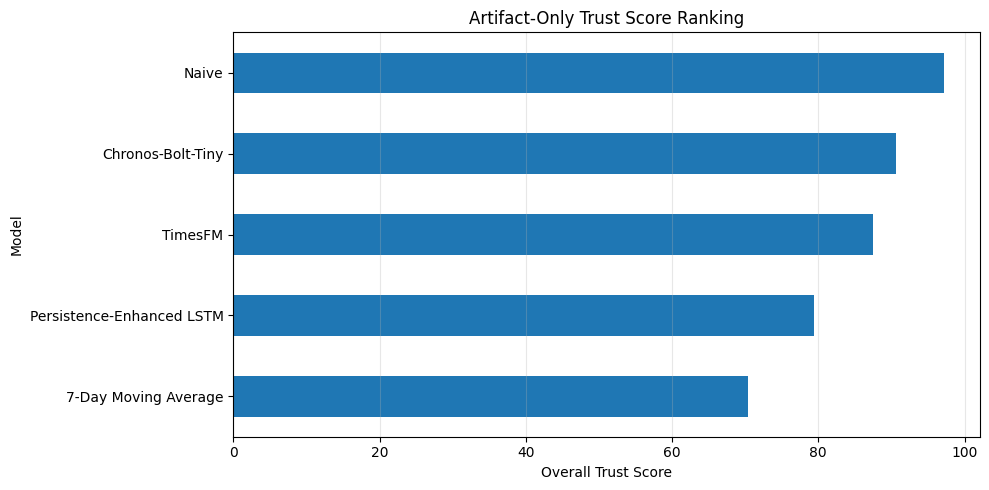

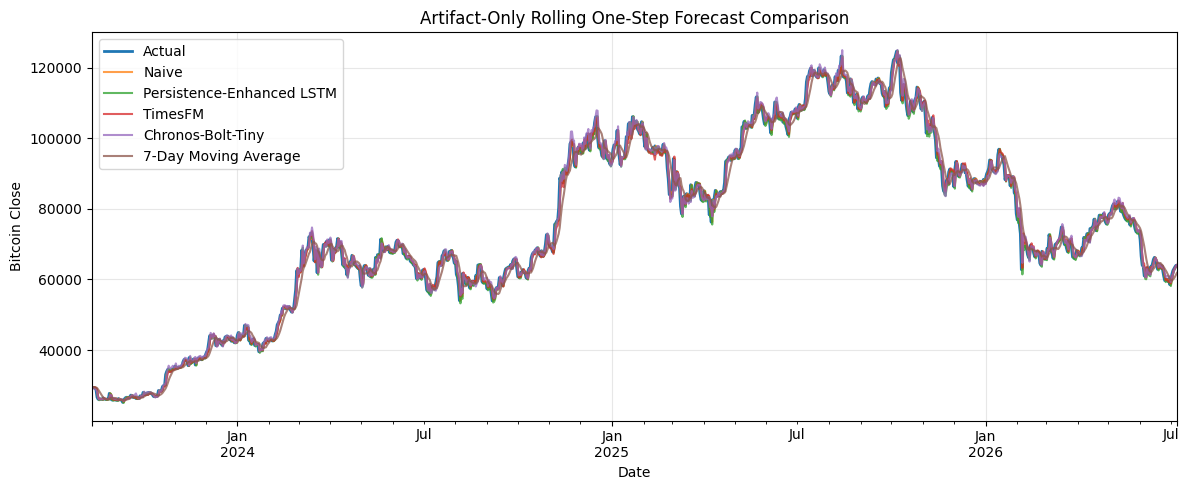

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
trust_scores["Overall Trust Score"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Artifact-Only Trust Score Ranking")
ax.set_xlabel("Overall Trust Score")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
for model_name, forecast in forecast_series.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.75)
ax.set_title("Artifact-Only Rolling One-Step Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Bitcoin Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Final Model Comparison

In [15]:
final_model_comparison = metrics_table.join(trust_scores[["Overall Trust Score"]], how="left").sort_values("Overall Trust Score", ascending=False)
final_model_comparison


,MAE,RMSE,MAPE,sMAPE,N,Relative MAE,Overall Trust Score
Model,,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,1061,1.000000,97.247439
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,1061,1.103594,90.577907
TimesFM,1349.946786,1924.199337,1.823179,1.823895,1061,1.046184,87.510746
Persistence-Enhanced LSTM,1323.040782,1886.566387,1.787392,1.794338,1061,1.025332,79.432539
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,1061,1.712536,70.429691


## 16. Authoritative Findings

- Naive has the best overall point accuracy.
- Persistence-Enhanced LSTM is the strongest supervised neural model with an exact saved forecast vector.
- Original LSTM has no exact saved validated forecast vector in `results/`, so it is excluded from the quantitative Trust Score ranking and retained only as an exploratory failure case study.
- TimesFM is the strongest zero-shot foundation model for point forecasts.
- Chronos provides better 80% uncertainty calibration.
- TimesFM has severe uncertainty undercoverage: its nominal 80% interval covers only `0.330820` of actual values.
- Model complexity does not guarantee trustworthiness.
- Different models dominate different trustworthiness dimensions.


## Appendix: Historical Model-Generation Workflow — Not Executed

Earlier versions of this notebook included model-fitting and model-inference code for ARIMA/SARIMA, raw-price LSTM, Persistence-Enhanced LSTM, Chronos, and later foundation-model comparisons. That code has been removed from the active execution path.

The historical methodology remains documented in the project notebooks that generated or audited the forecasts:
- `notebooks/05_Foundation_Models.ipynb`
- `notebooks/07_Model_Validation_Audit.ipynb`
- `notebooks/08_Naive_Forecast_Audit.ipynb`
- `notebooks/09_Statistical_Significance_Test.ipynb`

This notebook now consumes only validated forecast artifacts and deterministic baselines. It does not retrain, refit, load checkpoints, or regenerate model forecast vectors.
